#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from termcolor import colored
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#Load The Dataset

In [ ]:
file_link = 'https://drive.google.com/file/d/1QLUsdB0uUZDhXw8TKBGGln5p2zOmcFFS/view?usp=sharing'

id = file_link.split("/")[-2]

new_link = f'https://drive.google.com/uc?id={id}'
loan_data = pd.read_csv(new_link)

loan_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Female,No,0,Graduate,No,2138,0.0,99.0,360.0,0.0,Semiurban,N
1,Female,No,0,Graduate,No,2400,1863.0,104.0,360.0,0.0,Urban,N
2,Female,No,0,Graduate,No,3180,0.0,71.0,360.0,0.0,Urban,N
3,Female,No,0,Graduate,No,2138,0.0,99.0,360.0,0.0,Semiurban,N
4,Female,No,0,Graduate,No,4300,0.0,136.0,360.0,0.0,Semiurban,N


#Dataset Information

In [ ]:
print("Shape =", loan_data.shape)

rowNum, colNum = loan_data.shape
featureNum = colNum - 1

print(f"Number of Rows: {rowNum}")
print(f"Number of Columns: {colNum}")
print(f"Number of Features: {featureNum}")

Shape = (11715, 12)
Number of Rows: 11715
Number of Columns: 12
Number of Features: 11


In [ ]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11715 entries, 0 to 11714
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             10863 non-null  object 
 1   Married            11573 non-null  object 
 2   Dependents         10863 non-null  object 
 3   Education          11715 non-null  object 
 4   Self_Employed      10082 non-null  object 
 5   ApplicantIncome    11715 non-null  int64  
 6   CoapplicantIncome  11715 non-null  float64
 7   LoanAmount         11267 non-null  float64
 8   Loan_Amount_Term   11396 non-null  float64
 9   Credit_History     9585 non-null   float64
 10  Property_Area      11715 non-null  object 
 11  Loan_Status        11715 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 1.1+ MB


In [ ]:
loan_data.describe(include='all')

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,10863,11573,10863,11715,10082,11715.000000,11715.000000,11267.000000,11396.000000,9585.000000,11715,11715
unique,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,7455,6745,4899,7810,7171,NaN,NaN,NaN,NaN,NaN,4423,6319
mean,NaN,NaN,NaN,NaN,NaN,5615.355271,1535.646525,149.361143,339.398034,0.711111,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,6335.934238,3703.557065,94.888225,68.024814,0.453270,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2833.000000,0.000000,100.000000,360.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,3867.000000,484.000000,128.000000,360.000000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,5746.000000,2059.000000,161.000000,360.000000,1.000000,NaN,NaN


In [ ]:
loan_data.nunique()

,0
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,479
CoapplicantIncome,261
LoanAmount,197
Loan_Amount_Term,10
Credit_History,2


In [ ]:
loan_data.isnull().sum()

,0
Gender,852
Married,142
Dependents,852
Education,0
Self_Employed,1633
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,448
Loan_Amount_Term,319
Credit_History,2130


In [ ]:
cat_cols=loan_data.select_dtypes(include=['object']).columns.tolist()

num_cols = loan_data.select_dtypes(include=np.number).columns.tolist()

print("Categorical Variables:")
print(cat_cols)

print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
Numerical Variables:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


#Exploratory Data Analysis (EDA)

##Graphical Analysis (Gender)

Gender
Male      7455
Female    3408
NaN        852
Name: count, dtype: int64


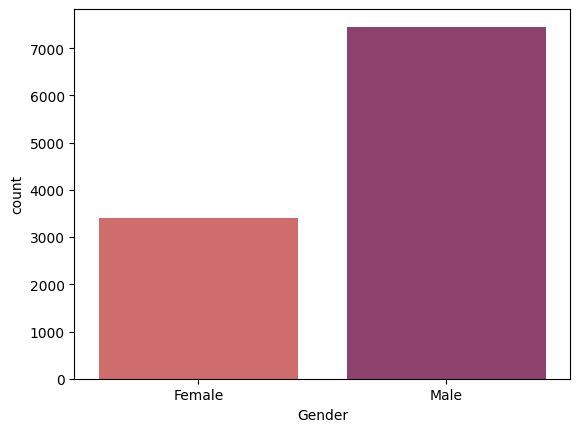

In [ ]:
GenderAnalysis = loan_data.Gender.value_counts(dropna=False)
print(GenderAnalysis)

sns.countplot(x="Gender", data=loan_data, palette="flare")
plt.show()

##Graphical Analysis (Marital Status)

Married
Yes    6745
No     4828
NaN     142
Name: count, dtype: int64


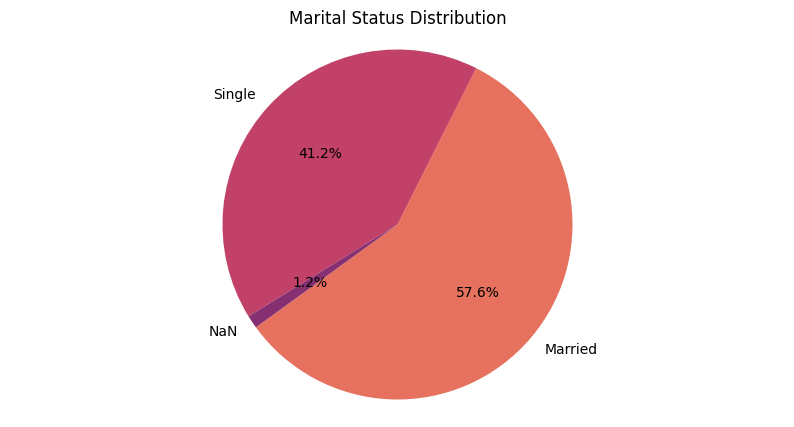

In [ ]:
MarriedAnalysis = loan_data.Married.value_counts(dropna=False)
print(MarriedAnalysis)

plt.figure(figsize=(10, 5))

plt.pie(MarriedAnalysis,
        labels=[("Married"),("Single"),("NaN")],
        startangle=216,
        autopct='%1.1f%%',
        colors=sns.color_palette("flare",
        len(MarriedAnalysis)))

plt.axis('equal')
plt.title('Marital Status Distribution')
plt.show()

Married
Yes    6745
No     4828
NaN     142
Name: count, dtype: int64


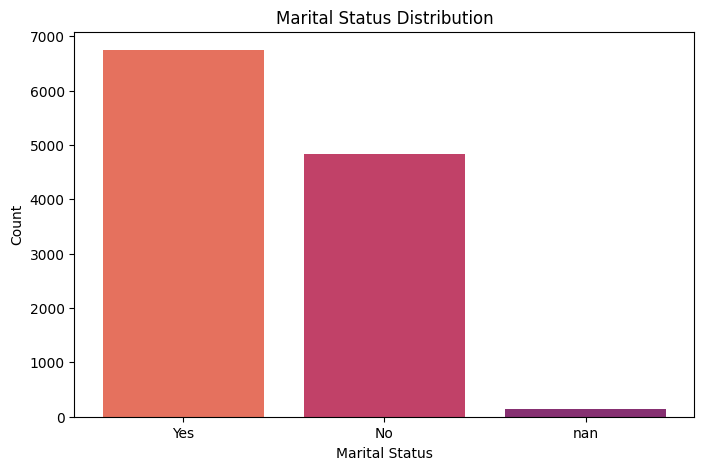

In [ ]:
MarriedAnalysis = loan_data.Married.value_counts(dropna=False)
print(MarriedAnalysis)

plt.figure(figsize=(8, 5))

# Bar plot
plt.bar(MarriedAnalysis.index.astype(str), MarriedAnalysis.values,
        color=sns.color_palette("flare", len(MarriedAnalysis)))

# Labels and title
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.title("Marital Status Distribution")

plt.show()

Dependents
0      4899
1      2627
2      1917
3+     1420
NaN     852
Name: count, dtype: int64


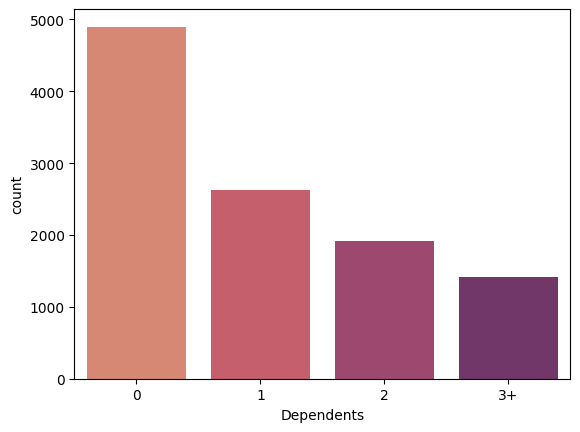

In [ ]:
DependentsAnalysis = loan_data.Dependents.value_counts(dropna=False)
print(DependentsAnalysis)

sns.countplot(x="Dependents", data=loan_data, palette="flare")
plt.show()

Education
Graduate        7810
Not Graduate    3905
Name: count, dtype: int64


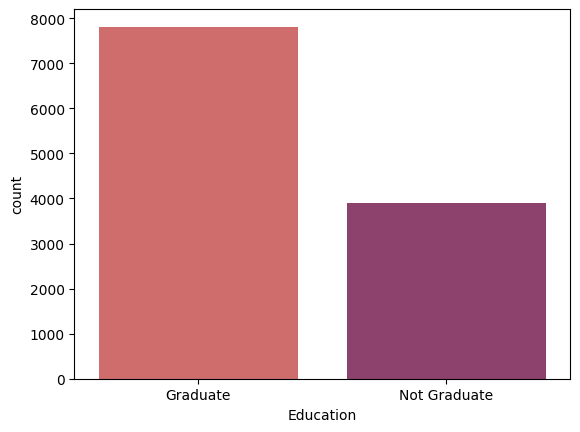

In [ ]:
EducationAnalysis = loan_data.Education.value_counts(dropna=False)
print(EducationAnalysis)

sns.countplot(x="Education", data=loan_data, palette="flare")
plt.show()

Self_Employed
No     7171
Yes    2911
NaN    1633
Name: count, dtype: int64


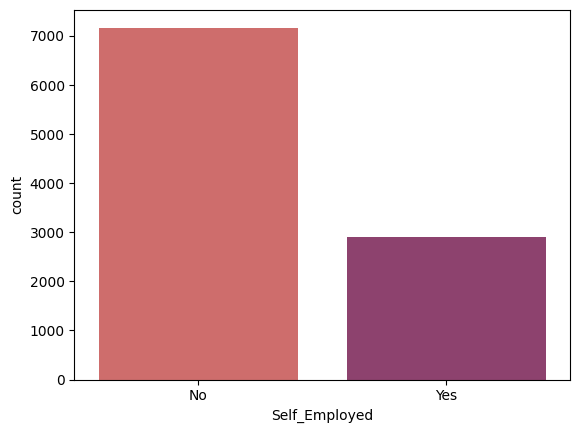

In [ ]:
Self_EmployedAnalysis = loan_data.Self_Employed.value_counts(dropna=False)
print(Self_EmployedAnalysis)

sns.countplot(x="Self_Employed", data=loan_data, palette="flare")
plt.show()

The Average Income: 5615.36 
The ratio of people with income above average to below average: 35.15 
Number of people income above the average: 3047
Number of people income below the average: 8668


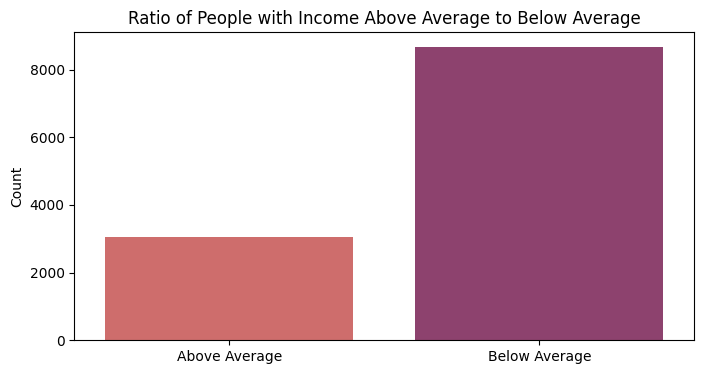

In [ ]:
average_income = loan_data['ApplicantIncome'].mean()
print(f"The Average Income: {average_income:.2f} ")

above_average_count = (loan_data['ApplicantIncome'] > average_income).sum()
below_average_count = (loan_data['ApplicantIncome'] <= average_income).sum()

ratio = above_average_count / below_average_count
print(f"The ratio of people with income above average to below average: {ratio*100:.2f} ")
print(f"Number of people income above the average: {above_average_count}")
print(f"Number of people income below the average: {below_average_count}")

plt.figure(figsize=(8, 4))
sns.barplot(x=['Above Average', 'Below Average'], y=[above_average_count, below_average_count], palette="flare")
plt.title('Ratio of People with Income Above Average to Below Average')
plt.ylabel('Count')
plt.show()

Credit_History
1.0    6816
0.0    2769
NaN    2130
Name: count, dtype: int64


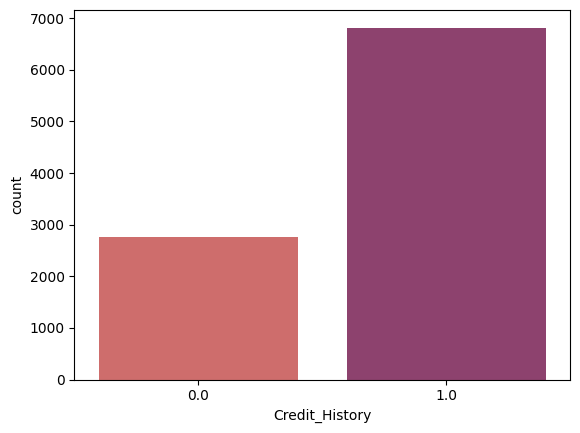

In [ ]:
Credit_HistoryAnalysis = loan_data.Credit_History.value_counts(dropna=False)
print(Credit_HistoryAnalysis)

sns.countplot(x="Credit_History", data=loan_data, palette="flare")
plt.show()

Property_Area
Semiurban    4423
Urban        3704
Rural        3588
Name: count, dtype: int64


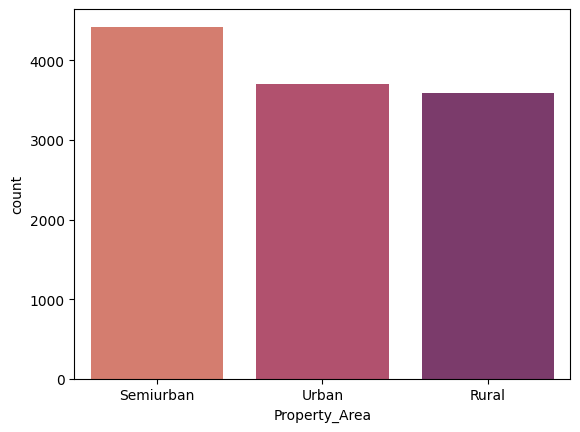

In [ ]:
Property_AreaAnalysis = loan_data.Property_Area.value_counts(dropna=False)
print(Property_AreaAnalysis)

sns.countplot(x="Property_Area", data=loan_data, palette="flare")
plt.show()

Loan_Status
Y    6319
N    5396
Name: count, dtype: int64


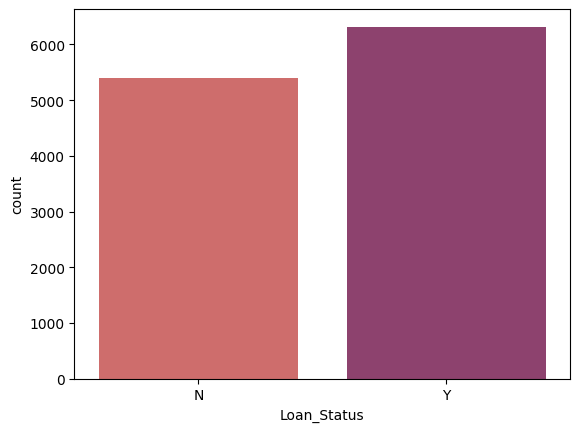

In [ ]:
Loan_StatusAnalysis = loan_data.Loan_Status.value_counts(dropna=False)
print(Loan_StatusAnalysis)

sns.countplot(x="Loan_Status", data=loan_data, palette="flare")
plt.show()

Loan_Amount_Term
360.0    9439
180.0    1049
480.0     340
NaN       319
300.0     205
240.0     179
84.0       96
60.0       37
36.0       31
120.0      15
12.0        5
Name: count, dtype: int64


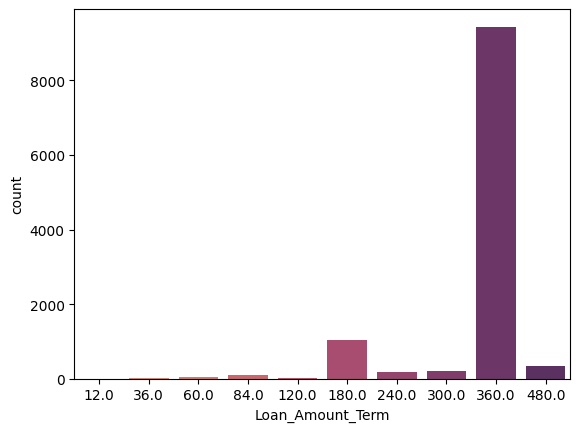

In [ ]:
Loan_Amount_TermAnalysis = loan_data.Loan_Amount_Term.value_counts(dropna=False)
print(Loan_Amount_TermAnalysis)

sns.countplot(x="Loan_Amount_Term", data=loan_data, palette="flare")
plt.show()

##Correlation Analysis

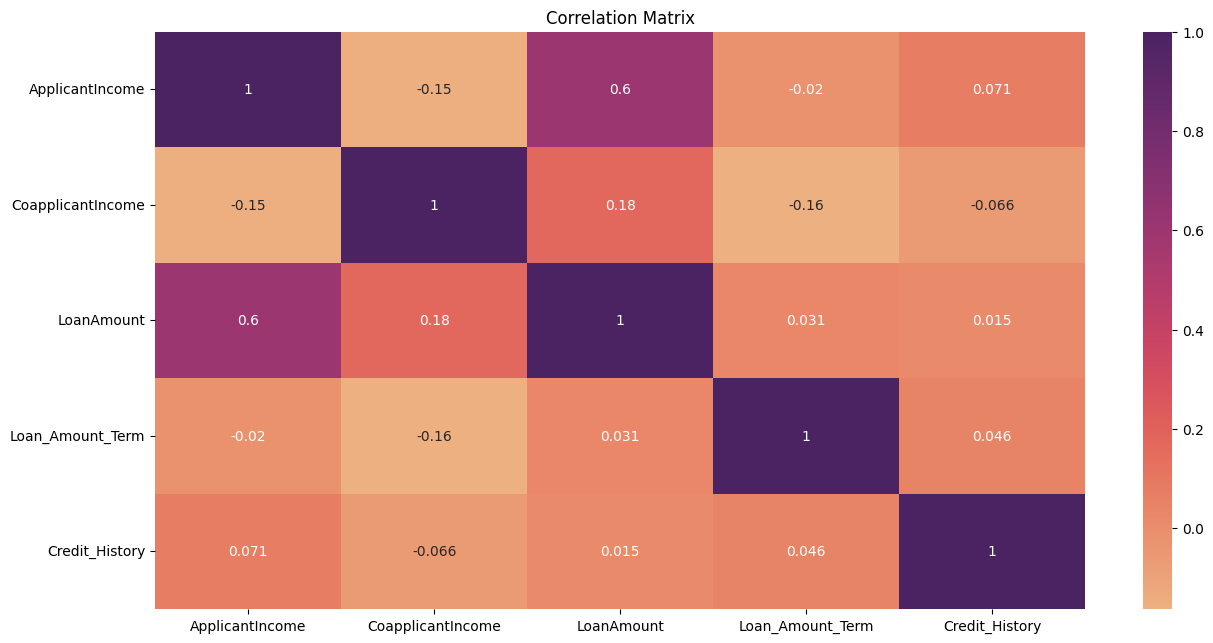

In [ ]:
correlation_matrix = loan_data.corr(numeric_only=True)

plt.figure(figsize=(15, 7.5))

sns.heatmap(correlation_matrix, annot=True, cmap='flare')

plt.title('Correlation Matrix')

plt.show()

##Data Relationships Analysis

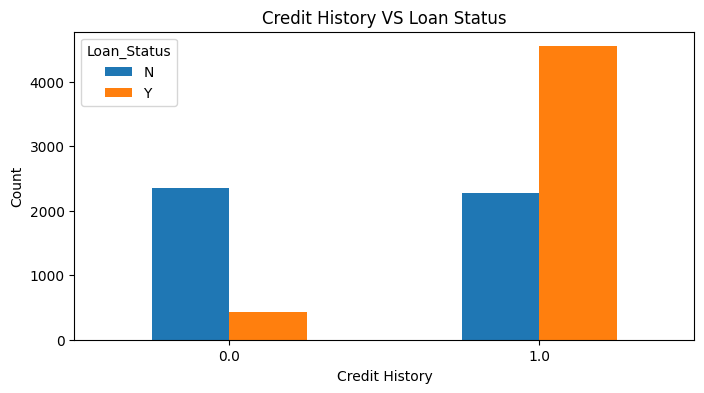

In [ ]:
pd.crosstab(loan_data.Credit_History, loan_data.Loan_Status).plot(kind="bar", figsize=(8, 4))

plt.title('Credit History VS Loan Status')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

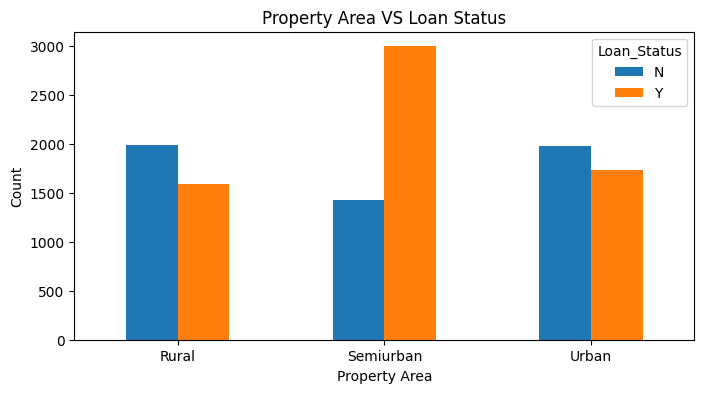

In [ ]:
pd.crosstab(loan_data.Property_Area, loan_data.Loan_Status).plot(kind="bar", figsize=(8, 4))

plt.title('Property Area VS Loan Status')
plt.xlabel('Property Area')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

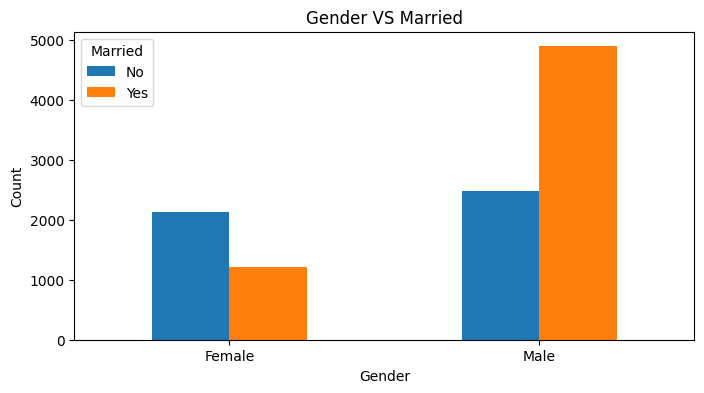

In [ ]:
pd.crosstab(loan_data.Gender, loan_data.Married).plot(kind="bar", figsize=(8, 4))

plt.title('Gender VS Married')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

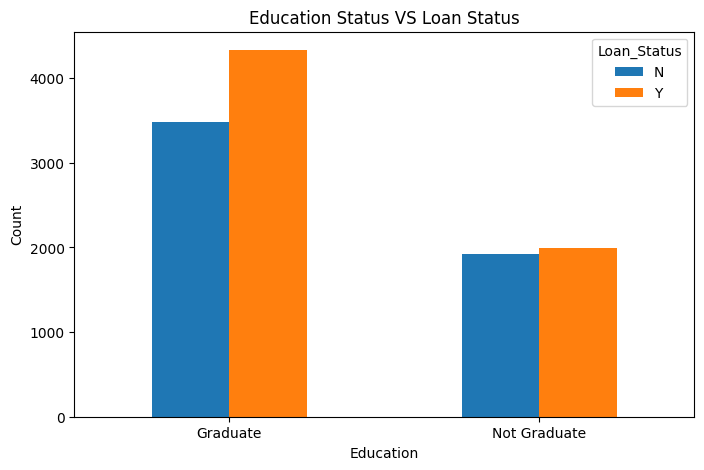

In [ ]:
pd.crosstab(loan_data.Education, loan_data.Loan_Status).plot(kind="bar", figsize=(8, 5))

plt.title('Education Status VS Loan Status')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

#Data Cleaning

##Remove Unneeded Features

In [ ]:
loan_data.drop(['Loan_ID'], axis=1, inplace=True, errors='ignore')

print(loan_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11715 entries, 0 to 11714
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             10863 non-null  object 
 1   Married            11573 non-null  object 
 2   Dependents         10863 non-null  object 
 3   Education          11715 non-null  object 
 4   Self_Employed      10082 non-null  object 
 5   ApplicantIncome    11715 non-null  int64  
 6   CoapplicantIncome  11715 non-null  float64
 7   LoanAmount         11267 non-null  float64
 8   Loan_Amount_Term   11396 non-null  float64
 9   Credit_History     9585 non-null   float64
 10  Property_Area      11715 non-null  object 
 11  Loan_Status        11715 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 1.1+ MB
None


##Handling Missing Values

In [ ]:
# Fill the missing values for numerical data.
loan_data["LoanAmount"] = loan_data["LoanAmount"].fillna(loan_data["LoanAmount"].mean())

loan_data["Loan_Amount_Term"] = loan_data["Loan_Amount_Term"].fillna(loan_data["Loan_Amount_Term"].mode()[0])

loan_data["Credit_History"] = loan_data["Credit_History"].fillna(loan_data["Credit_History"].mode()[0])




# Fill the missing values for categorical data.
loan_data["Gender"] = loan_data["Gender"].fillna(loan_data["Gender"].mode()[0])
loan_data["Married"] = loan_data["Married"].fillna(loan_data["Married"].mode()[0])
loan_data["Dependents"] = loan_data["Dependents"].fillna(loan_data["Dependents"].mode()[0])
loan_data["Self_Employed"] = loan_data["Self_Employed"].fillna(loan_data["Self_Employed"].mode()[0])

In [ ]:
# Check for missing values after handling
null_counts = loan_data.isnull().sum()

# Display the number of null values after handling
print(null_counts)

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


##One-Hot Encoding For Categorical Variables

In [ ]:
# One-hot encode categorical columns
loan_data = pd.get_dummies(loan_data)

# Drop redundant dummy variables
loan_data.drop(['Gender_Female', 'Married_No', 'Education_Not Graduate',
                'Self_Employed_No', 'Loan_Status_N'], axis=1, inplace=True)

# Rename columns
loan_data.rename(columns={
    'Gender_Male': 'Gender',
    'Married_Yes': 'Married',
    'Education_Graduate': 'Education',
    'Self_Employed_Yes': 'Self_Employed',
    'Loan_Status_Y': 'Loan_Status'
}, inplace=True)

# Show dataset info
print("Column Names:", list(loan_data.columns))
print("Shape:", loan_data.shape)
print(loan_data['Loan_Status'].head())

Column Names: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender', 'Married', 'Dependents_0', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education', 'Self_Employed', 'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Status']
Shape: (11715, 17)
0    False
1    False
2    False
3    False
4    False
Name: Loan_Status, dtype: bool


#LR

In [ ]:
X = loan_data.iloc[:, :-1]  # all columns except the last one
y = loan_data.iloc[:, -1]   # the last column

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#check for accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
#can also use classifiation_report metrics for more details

Accuracy: 0.7084933845497225


#Data Preprocessing

In [ ]:
X = loan_data.drop(columns=['Loan_Status'])

Y = loan_data['Loan_Status']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (11715, 16)
Shape of Y: (11715,)


In [ ]:
min_max_scaler = MinMaxScaler()
X = min_max_scaler.fit_transform(X)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (9372, 16)
Shape of X_test: (2343, 16)
Shape of Y_train: (9372,)
Shape of Y_test: (2343,)


#Random Forest

In [ ]:
scoreListRF_Train = []
scoreListRF_Test = []

for max_dep in range(1, 10):
    for rand_state in range(1, 50):
        for n_est in range(1, 30):
            ModelRF = RandomForestClassifier(n_estimators=n_est, random_state=rand_state, max_depth=max_dep)

            ModelRF.fit(X_train, Y_train)

            scoreListRF_Train.append(ModelRF.score(X_train, Y_train))

            scoreListRF_Test.append(ModelRF.score(X_test, Y_test))

RF_Accuracy_Train = max(scoreListRF_Train)
RF_Accuracy_Test = max(scoreListRF_Test)

print(f"Random Forest best accuracy (Training): {RF_Accuracy_Train*100:.2f}%")
print(f"Random Forest best accuracy (Testing): {RF_Accuracy_Test*100:.2f}%")

Random Forest best accuracy (Training): 99.30%
Random Forest best accuracy (Testing): 98.98%


#Logistic Regression

In [ ]:
scoreListLR_Train = []
scoreListLR_Test = []

for i in range(1, 150):
    for j in range(1, 10):
        ModelLR= LogisticRegression(random_state=i, solver='saga', max_iter=j)

        ModelLR.fit(X_train,Y_train)

        scoreListLR_Train.append(ModelLR.score(X_train, Y_train))

        scoreListLR_Test.append(ModelLR.score(X_test, Y_test))

LR_Accuracy_Train = max(scoreListLR_Train)
LR_Accuracy_Test = max(scoreListLR_Test)

print(f"Logistic Regression best accuracy (Training): {LR_Accuracy_Train*100:.2f}%")
print(f"Logistic Regression best accuracy (Testing): {LR_Accuracy_Test*100:.2f}%")



Logistic Regression best accuracy (Training): 56.76%
Logistic Regression best accuracy (Testing): 55.61%


In [ ]:
X = loan_data.iloc[:, :-1]  # all columns except the last one
Y = loan_data.iloc[:, -1]   # the last column

# Split into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

#check for accuracy
print("Accuracy:", accuracy_score(Y_test, y_pred))
#can also use classifiation_report metrics for more details

Accuracy: 0.7084933845497225
